# Project 10 (Notebook 1/3) — PBMC 3k pipeline in Scanpy (Python)

**Dataset:** 10X Genomics PBMC 3k (2,700 cells, 32,738 genes), raw counts.

**Goal:** run a clean Scanpy pipeline from raw counts to annotated clusters. Save embeddings, clusters, and marker genes for cross-platform comparison with the Seurat pipeline (notebook 2) and the comparison metrics (notebook 3).

**Identical-parameters policy.** Both ecosystems use the same: `min_cells=3`, `min_genes=200`, `pct.mito<5%`, `n_top_HVG=2000`, `n_PCs=30`, `k_neighbors=15`, `clustering_resolution=0.5`, `random_seed=42`. The pipeline steps are: filter -> normalize -> log1p -> HVG -> scale -> PCA -> neighbors -> UMAP -> Leiden -> marker genes.

## 1. Setup

In [1]:
import os
import sys
import time
import json
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/marko-b2/upwork_portfolio/_shared/scripts')
try:
    from portfolio_utils import save_fig
    plt.style.use('/home/marko-b2/upwork_portfolio/_shared/styles/portfolio.mplstyle')
except Exception:
    def save_fig(fig, path, dpi=300):
        fig.savefig(path, dpi=dpi, bbox_inches='tight')

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, fontsize=10)

FIG_DIR = '../figures'
RES_DIR = '../results'
for d in [FIG_DIR, RES_DIR]:
    os.makedirs(d, exist_ok=True)

SEED = 42
np.random.seed(SEED)

print(f'scanpy: {sc.__version__}')
print(f'numpy:  {np.__version__}')

scanpy: 1.11.5
numpy:  2.4.6


## 2. Load raw counts

In [2]:
raw_path = '/home/marko-b2/upwork_portfolio/01_pbmc3k_basics/notebooks/data/pbmc3k_raw.h5ad'
adata = sc.read(raw_path)
adata.var_names_make_unique()
print(adata)
print(f'X max value: {adata.X.max():.1f} (should be raw counts, >>50)')

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
X max value: 419.0 (should be raw counts, >>50)


## 3. QC filter

Apply identical filter thresholds to what Seurat will use:
- min_cells=3 (gene must appear in at least 3 cells)
- min_genes=200 (cell must express at least 200 genes)
- pct_mito < 5%

In [3]:
t0 = time.time()
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

print(f'Before QC: {adata.n_obs} cells, {adata.n_vars} genes')
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 5, :].copy()
print(f'After QC:  {adata.n_obs} cells, {adata.n_vars} genes')
qc_time = time.time() - t0
print(f'QC step: {qc_time:.1f}s')

Before QC: 2700 cells, 32738 genes
After QC:  2643 cells, 13714 genes
QC step: 0.2s


## 4. Normalize + log1p + HVG + scale + PCA

In [4]:
t0 = time.time()
# Normalize to 10k counts per cell (matches Seurat's LogNormalize scale.factor=10000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# HVG (2000 top), seurat flavor for parity with R Seurat::FindVariableFeatures(method='vst')
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat_v3', layer=None)
# seurat_v3 needs raw counts; if it fails, fall back to seurat flavor on log-norm
if adata.var['highly_variable'].sum() == 0:
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
print(f'HVGs: {int(adata.var.highly_variable.sum())}')

# Subset to HVG for scale + PCA
adata_hvg = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.pp.pca(adata_hvg, n_comps=50, random_state=SEED)

# Carry PCA back to full adata
adata.obsm['X_pca'] = adata_hvg.obsm['X_pca']
adata.uns['pca'] = adata_hvg.uns['pca']

prep_time = time.time() - t0
print(f'Preprocessing: {prep_time:.1f}s')
print(f'PCA shape: {adata.obsm["X_pca"].shape}')

HVGs: 2000


Preprocessing: 1.1s
PCA shape: (2643, 50)


## 5. Neighbors + UMAP + Leiden

In [5]:
t0 = time.time()
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, random_state=SEED)
sc.tl.umap(adata, random_state=SEED)
sc.tl.leiden(adata, resolution=0.5, random_state=SEED, flavor='igraph', n_iterations=2, directed=False)
umap_time = time.time() - t0
print(f'Neighbors+UMAP+Leiden: {umap_time:.1f}s')
print(f'Number of Leiden clusters: {adata.obs.leiden.nunique()}')
print(adata.obs.leiden.value_counts().sort_index())

Neighbors+UMAP+Leiden: 6.0s
Number of Leiden clusters: 8
leiden
0    338
1    354
2    644
3    476
4    177
5    150
6    472
7     32
Name: count, dtype: int64


## 6. Marker genes per cluster

In [6]:
t0 = time.time()
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')
marker_time = time.time() - t0
print(f'rank_genes_groups: {marker_time:.1f}s')

# Extract top 50 markers per cluster as a tidy DataFrame
marker_records = []
for cl in sorted(adata.obs.leiden.unique(), key=lambda x: int(x)):
    top = sc.get.rank_genes_groups_df(adata, group=cl).head(50)
    top['cluster'] = cl
    top['rank'] = np.arange(1, len(top) + 1)
    marker_records.append(top)
marker_df = pd.concat(marker_records, ignore_index=True)
marker_df = marker_df[['cluster', 'rank', 'names', 'scores', 'pvals', 'pvals_adj', 'logfoldchanges']]
marker_df.columns = ['cluster', 'rank', 'gene', 'score', 'pval', 'pval_adj', 'logfc']
marker_df.to_csv(f'{RES_DIR}/python_markers_top50.csv', index=False)
print(f'Saved markers: {marker_df.shape}')
print('\nTop 5 markers per cluster:')
for cl in sorted(adata.obs.leiden.unique(), key=lambda x: int(x)):
    top5 = marker_df.query(f'cluster == "{cl}"').head(5)['gene'].tolist()
    print(f'  Cluster {cl}: {top5}')

rank_genes_groups: 0.3s
Saved markers: (400, 7)

Top 5 markers per cluster:
  Cluster 0: ['CCL5', 'NKG7', 'B2M', 'IL32', 'CST7']
  Cluster 1: ['CD74', 'CD79A', 'HLA-DRA', 'CD79B', 'HLA-DPB1']
  Cluster 2: ['LTB', 'IL32', 'LDHB', 'CD3D', 'IL7R']
  Cluster 3: ['LYZ', 'S100A9', 'S100A8', 'TYROBP', 'FTL']
  Cluster 4: ['LST1', 'COTL1', 'SAT1', 'FTH1', 'FCER1G']
  Cluster 5: ['NKG7', 'GNLY', 'GZMB', 'CTSW', 'PRF1']
  Cluster 6: ['RPL32', 'RPS12', 'RPS27', 'RPS6', 'RPL9']
  Cluster 7: ['HLA-DPB1', 'HLA-DPA1', 'HLA-DQA1', 'HLA-DRA', 'HLA-DRB1']


## 7. Cell-type annotation (canonical PBMC markers)

Manual annotation using the standard PBMC 3k tutorial markers:
- CD3D/CD3E -> T cells
- IL7R -> CD4 T (memory)
- CD8A -> CD8 T
- GNLY/NKG7 -> NK
- MS4A1/CD79A -> B cells
- LYZ/CD14 -> Mono CD14+
- FCGR3A/MS4A7 -> Mono FCGR3A+
- FCER1A/CST3 -> DC
- PPBP -> Platelets

In [7]:
# Decide annotation by inspecting top markers per cluster
cluster_to_label = {}
marker_signatures = {
    'CD4 T':     ['IL7R', 'CCR7', 'TCF7', 'LTB'],
    'CD8 T':     ['CD8A', 'CD8B', 'GZMK'],
    'NK':        ['GNLY', 'NKG7', 'FCGR3A', 'GZMB', 'PRF1'],
    'B':         ['MS4A1', 'CD79A', 'CD79B', 'IGHM', 'CD19'],
    'Mono CD14': ['CD14', 'LYZ', 'S100A8', 'S100A9'],
    'Mono FCGR3A': ['FCGR3A', 'MS4A7', 'CDKN1C'],
    'DC':        ['FCER1A', 'CST3', 'CLEC10A'],
    'Platelet':  ['PPBP', 'PF4', 'ITGA2B'],
}

# For each cluster, score each signature and assign highest-scoring label
cluster_signature_scores = {}
for cl in sorted(adata.obs.leiden.unique(), key=lambda x: int(x)):
    cl_markers = set(marker_df.query(f'cluster == "{cl}"').head(30)['gene'])
    scores = {}
    for label, sig in marker_signatures.items():
        overlap = len(set(sig) & cl_markers)
        scores[label] = overlap
    best_label = max(scores, key=scores.get)
    if scores[best_label] == 0:
        best_label = f'Unknown_{cl}'
    cluster_to_label[cl] = best_label
    cluster_signature_scores[cl] = scores
    print(f'Cluster {cl} -> {best_label}  (overlap scores: {scores})')

# Disambiguate duplicates by appending cluster id
label_counts = pd.Series(list(cluster_to_label.values())).value_counts()
for label, count in label_counts.items():
    if count > 1:
        clusters_with_label = [c for c, l in cluster_to_label.items() if l == label]
        for c in clusters_with_label:
            cluster_to_label[c] = f'{label}_{c}'

adata.obs['celltype'] = adata.obs['leiden'].map(cluster_to_label).astype('category')
print('\nFinal cluster -> celltype mapping:')
for cl in sorted(cluster_to_label.keys(), key=lambda x: int(x)):
    print(f'  {cl}: {cluster_to_label[cl]}')

Cluster 0 -> CD8 T  (overlap scores: {'CD4 T': 0, 'CD8 T': 3, 'NK': 2, 'B': 0, 'Mono CD14': 0, 'Mono FCGR3A': 0, 'DC': 0, 'Platelet': 0})
Cluster 1 -> B  (overlap scores: {'CD4 T': 1, 'CD8 T': 0, 'NK': 0, 'B': 3, 'Mono CD14': 0, 'Mono FCGR3A': 0, 'DC': 0, 'Platelet': 0})
Cluster 2 -> CD4 T  (overlap scores: {'CD4 T': 2, 'CD8 T': 0, 'NK': 0, 'B': 0, 'Mono CD14': 0, 'Mono FCGR3A': 0, 'DC': 0, 'Platelet': 0})
Cluster 3 -> Mono CD14  (overlap scores: {'CD4 T': 0, 'CD8 T': 0, 'NK': 0, 'B': 0, 'Mono CD14': 3, 'Mono FCGR3A': 0, 'DC': 1, 'Platelet': 0})
Cluster 4 -> Mono FCGR3A  (overlap scores: {'CD4 T': 0, 'CD8 T': 0, 'NK': 1, 'B': 0, 'Mono CD14': 0, 'Mono FCGR3A': 2, 'DC': 1, 'Platelet': 0})
Cluster 5 -> NK  (overlap scores: {'CD4 T': 0, 'CD8 T': 0, 'NK': 5, 'B': 0, 'Mono CD14': 0, 'Mono FCGR3A': 1, 'DC': 0, 'Platelet': 0})
Cluster 6 -> Unknown_6  (overlap scores: {'CD4 T': 0, 'CD8 T': 0, 'NK': 0, 'B': 0, 'Mono CD14': 0, 'Mono FCGR3A': 0, 'DC': 0, 'Platelet': 0})
Cluster 7 -> DC  (overlap s

## 8. Hero figure: UMAP by cluster + UMAP by celltype + marker dotplot

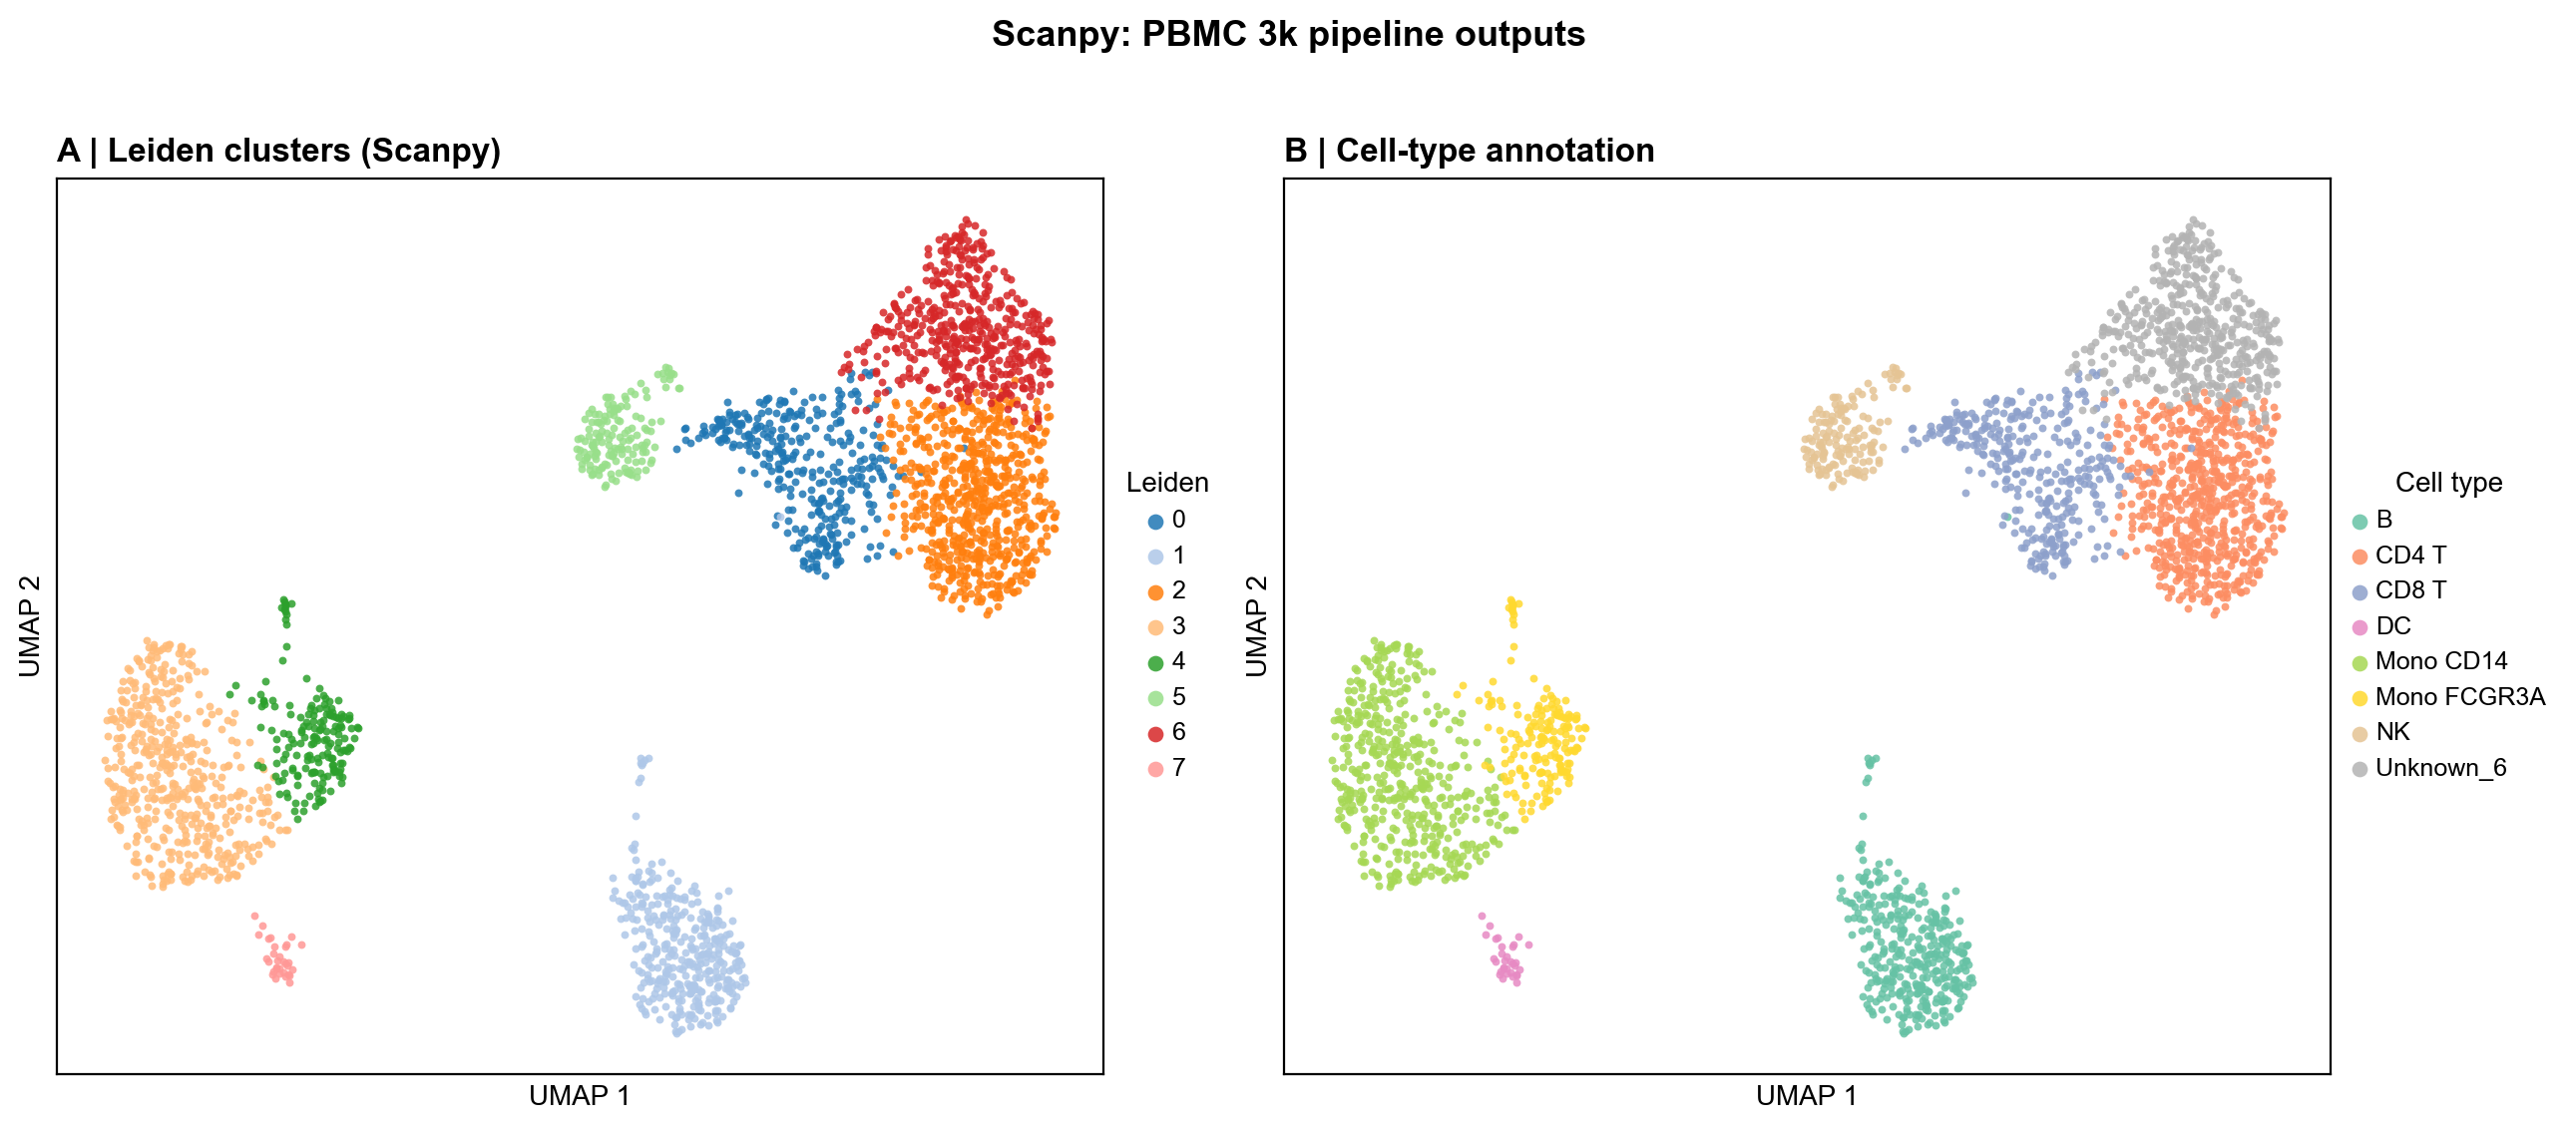

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
umap = adata.obsm['X_umap']

# Panel A: clusters
ax = axes[0]
clusters = adata.obs.leiden.astype(str)
uniq_c = sorted(clusters.unique(), key=lambda x: int(x))
palette_c = sns.color_palette('tab20', n_colors=len(uniq_c))
color_map_c = dict(zip(uniq_c, palette_c))
for c in uniq_c:
    m = (clusters == c).values
    ax.scatter(umap[m, 0], umap[m, 1], s=8, c=[color_map_c[c]], label=c, alpha=0.85, linewidth=0)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, markerscale=2, title='Leiden')
ax.set_title('A | Leiden clusters (Scanpy)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])

# Panel B: cell types
ax = axes[1]
labels = adata.obs.celltype.astype(str)
uniq_l = sorted(labels.unique())
palette_l = sns.color_palette('Set2', n_colors=len(uniq_l))
color_map_l = dict(zip(uniq_l, palette_l))
for l in uniq_l:
    m = (labels == l).values
    ax.scatter(umap[m, 0], umap[m, 1], s=8, c=[color_map_l[l]], label=l, alpha=0.85, linewidth=0)
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False, markerscale=2, title='Cell type')
ax.set_title('B | Cell-type annotation', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Scanpy: PBMC 3k pipeline outputs', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, f'{FIG_DIR}/python_umap.png', dpi=300)
plt.show()

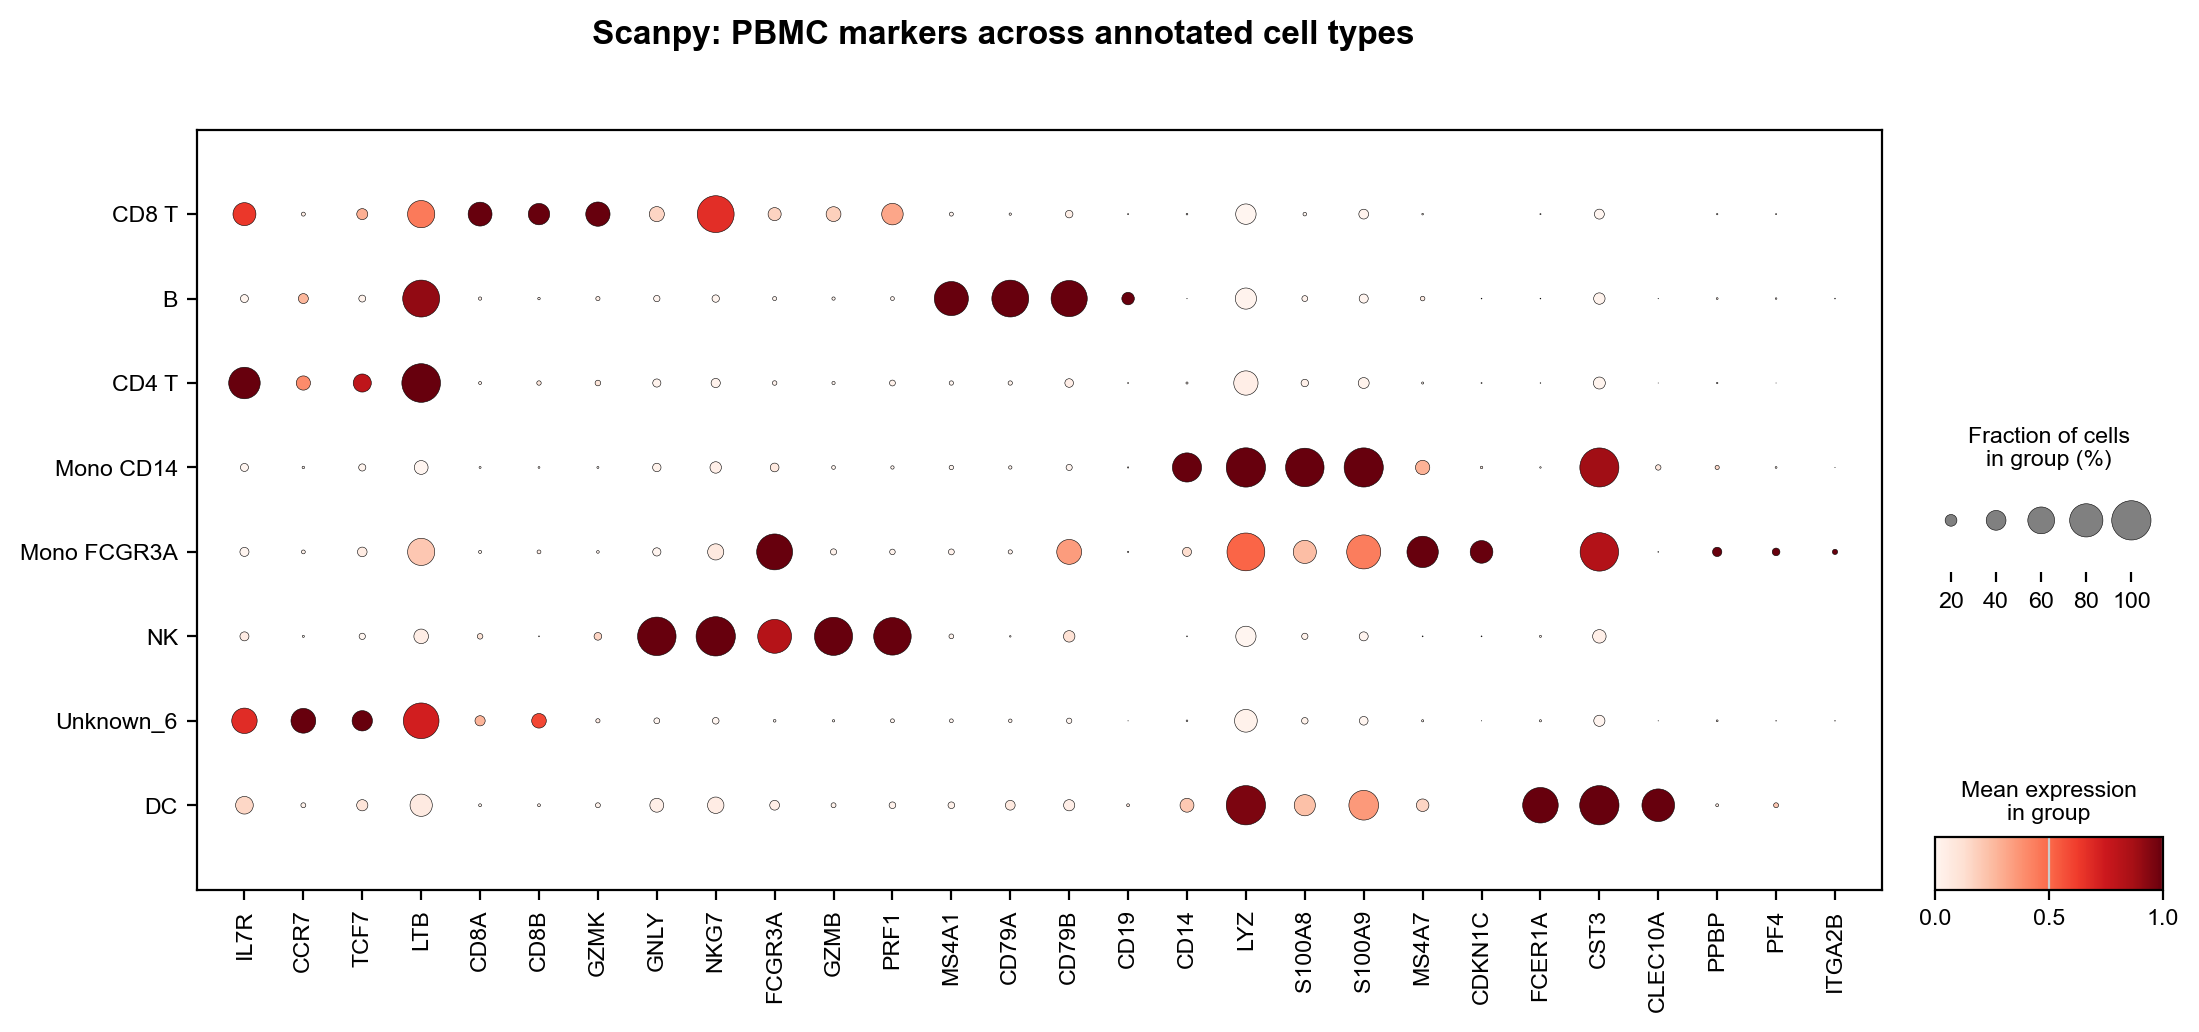

In [9]:
# Marker dotplot
marker_flat = []
for sig in marker_signatures.values():
    marker_flat.extend([g for g in sig if g in adata.var_names])
marker_flat = list(dict.fromkeys(marker_flat))  # preserve order, drop dupes

sc.pl.dotplot(adata, marker_flat, groupby='celltype', show=False,
              standard_scale='var', cmap='Reds', figsize=(max(8, 0.45 * len(marker_flat)), 5))
fig = plt.gcf()
plt.suptitle('Scanpy: PBMC markers across annotated cell types', fontsize=12, fontweight='bold', y=1.02)
save_fig(fig, f'{FIG_DIR}/python_marker_dotplot.png', dpi=300)
plt.show()

## 9. Save outputs for comparison notebook

In [10]:
# Per-cell DataFrame: cluster, celltype, UMAP1, UMAP2, top PCs
per_cell = pd.DataFrame({
    'cell': adata.obs_names,
    'leiden': adata.obs.leiden.values,
    'celltype': adata.obs.celltype.values,
    'UMAP1': umap[:, 0],
    'UMAP2': umap[:, 1],
})
for i in range(min(30, adata.obsm['X_pca'].shape[1])):
    per_cell[f'PC{i+1}'] = adata.obsm['X_pca'][:, i]
per_cell.to_csv(f'{RES_DIR}/python_per_cell.csv', index=False)

# Save processed adata
adata.write(f'{RES_DIR}/python_pbmc3k_processed.h5ad')

# Save summary
summary = {
    'ecosystem': 'Scanpy (Python)',
    'scanpy_version': sc.__version__,
    'n_cells_after_qc': int(adata.n_obs),
    'n_genes_after_qc': int(adata.n_vars),
    'n_hvg': int(adata.var.highly_variable.sum()),
    'n_pcs': 50,
    'n_leiden_clusters': int(adata.obs.leiden.nunique()),
    'cluster_sizes': adata.obs.leiden.value_counts().sort_index().to_dict(),
    'cluster_to_celltype': {k: str(v) for k, v in cluster_to_label.items()},
    'celltypes': sorted(adata.obs.celltype.astype(str).unique().tolist()),
    'runtime_sec': {
        'qc': float(qc_time),
        'preprocessing': float(prep_time),
        'umap_clustering': float(umap_time),
        'marker_genes': float(marker_time),
        'total': float(qc_time + prep_time + umap_time + marker_time),
    },
    'seed': SEED,
}
with open(f'{RES_DIR}/python_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Saved:')
print(f'  {RES_DIR}/python_per_cell.csv')
print(f'  {RES_DIR}/python_pbmc3k_processed.h5ad')
print(f'  {RES_DIR}/python_summary.json')
print(f'  {RES_DIR}/python_markers_top50.csv')
print(f'\nTotal pipeline time: {summary["runtime_sec"]["total"]:.1f}s')

Saved:
  ../results/python_per_cell.csv
  ../results/python_pbmc3k_processed.h5ad
  ../results/python_summary.json
  ../results/python_markers_top50.csv

Total pipeline time: 7.6s
